# Improved Hallucination Detection Baselines

This notebook upgrades the original baseline evaluation in three ways:

1. It rebuilds the clean ToolACE split directly from the original dataset.
2. It evaluates on a combined benchmark made of `clean + 3 hallucination datasets` from `datasets/`.
3. It trains stronger sample-level detectors on real labels and reports both overall and per-type metrics.

The goal is to benchmark hallucination detection for:
- `tool_output_contradiction`
- `overgeneration`
- `missing_tool`


In [30]:
# Install additional packages if needed.
%pip install -q lettucedetect scikit-learn transformers matplotlib seaborn accelerate


Note: you may need to restart the kernel to use updated packages.


In [31]:
import os

os.chdir("/workspace/skoltech/hw_gen_ai1")

print(os.getcwd())

/workspace/skoltech/hw_gen_ai1


## 1. Imports and setup


In [32]:
import copy
import json
import random
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)

from evaluation_baselines_span_utils import (
    add_normalized_context_columns,
    aggregate_lookback_features,
    aggregate_span_features,
    build_span_eval_frame,
    lexical_hallucination_spans,
    merge_spans,
    spans_from_lookback_ratios,
)

seed = 1241
random.seed(seed)
np.random.seed(seed)

sns.set_theme(style="whitegrid")


## 2. Rebuild the clean ToolACE dataset

The assignment requires the original dataset to be loaded from:

```python
init_dataset = pd.read_json("hf://datasets/Team-ACE/ToolACE/data.json")
```


In [33]:
init_dataset = pd.read_json("hf://datasets/Team-ACE/ToolACE/data.json")
print(f"Loaded raw ToolACE rows: {len(init_dataset)}")
init_dataset.head(2)


Loaded raw ToolACE rows: 11300


,system,conversations
0,You are an expert in composing functions. You ...,"[{'from': 'user', 'value': 'I'm considering in..."
1,You are an expert in composing functions. You ...,"[{'from': 'user', 'value': 'Could you please f..."


In [34]:
def tool_responses_to_text(responses):
    parts = []
    for response in responses:
        parts.append(f"{response['name']}: {json.dumps(response['results'], ensure_ascii=False)}")
    return "\n".join(parts)


def parse_one_conversation(conv):
    res = []
    n = len(conv)
    i = 0

    while i < n:
        if conv[i].get("from") != "tool":
            i += 1
            continue

        context = copy.deepcopy(json.loads(conv[i]["value"]))
        entry = {}

        j = i
        while j >= 0 and conv[j].get("from") != "user":
            j -= 1
        if j < 0:
            i += 1
            continue
        entry["query"] = conv[j]["value"]

        j = i + 1
        while j < n:
            role = conv[j].get("from")
            if role == "assistant":
                val = conv[j]["value"]
                if val.startswith("[") and val.endswith("]"):
                    j += 1
                    continue
                break
            if role == "tool":
                context += json.loads(conv[j]["value"])
                i = j
            j += 1

        if j >= n:
            i += 1
            continue

        entry["context"] = tool_responses_to_text(context)
        entry["output"] = conv[j]["value"]
        res.append(entry)
        i += 1

    return res


def extract_tools_list_from_system(system_text: str):
    anchor = "Here is a list of functions"
    start_pos = system_text.find(anchor)
    s = system_text[start_pos:] if start_pos != -1 else system_text

    i0 = s.find("[")
    if i0 == -1:
        return None

    depth = 0
    in_str = False
    quote = ""
    esc = False
    start = None

    for i in range(i0, len(s)):
        ch = s[i]

        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == quote:
                in_str = False
            continue

        if ch in ('"', "'"):
            in_str = True
            quote = ch
            continue

        if ch == "[":
            if depth == 0:
                start = i
            depth += 1
        elif ch == "]":
            if depth > 0:
                depth -= 1
                if depth == 0 and start is not None:
                    block = s[start:i + 1]
                    try:
                        obj = json.loads(block)
                    except Exception:
                        return None
                    if isinstance(obj, list) and all(isinstance(x, dict) for x in obj):
                        return obj
                    return None
    return None


In [35]:
correct_dataset = []

for row in init_dataset.itertuples():
    parsed_conv = parse_one_conversation(row.conversations)
    parsed_tool_list = extract_tools_list_from_system(row.system)

    if parsed_tool_list and parsed_conv:
        tool_meta = [{k: t[k] for k in ("name", "description") if k in t} for t in parsed_tool_list]
        for request in parsed_conv:
            request["context"] = f"{request['context']}\nAvailable tools: {json.dumps(tool_meta, ensure_ascii=False)}"

    correct_dataset.extend(parsed_conv)

print(f"Recovered clean ToolACE-style samples: {len(correct_dataset)}")
pd.DataFrame(correct_dataset).head(3)


Recovered clean ToolACE-style samples: 1034


,query,context,output
0,I'm considering investing and I'd like to know...,"Market Trends API: {""trends"": [{""name"": ""S&P 5...",Here are the top Market Trends in the US right...
1,"Could you please find me some quotes about ""in...","Quotes by Keywords: {""quotes"": [{""text"": ""The ...",Here are some inspiration quotes for you:\n\n1...
2,Can you dig up some juicy details about the zi...,"Get Zip Code Information: {""information"": ""Zip...",Here's the detailed information about the zip ...


## 3. Load the three hallucination datasets and build one benchmark


In [36]:
DATA_DIR = Path("datasets")
CORRUPTION_FILES = {
    "tool_output_contradiction": DATA_DIR / "tool_output_contradiction_dataset.jsonl",
    "overgeneration": DATA_DIR / "overgeneration_dataset.jsonl",
    "missing_tool": DATA_DIR / "missing_tool_dataset.jsonl",
}


def load_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


corrupted_datasets = {name: load_jsonl(path) for name, path in CORRUPTION_FILES.items()}
for name, rows in corrupted_datasets.items():
    print(f"{name:28s} -> {len(rows)} rows")


tool_output_contradiction    -> 1034 rows
overgeneration               -> 1034 rows
missing_tool                 -> 1034 rows


In [37]:
def is_hallucinated(row):
    return int(len(row.get("hallucination_labels", [])) > 0)


n_clean = len(correct_dataset)
for name, rows in corrupted_datasets.items():
    assert len(rows) == n_clean, f"Length mismatch for {name}: {len(rows)} vs {n_clean}"

benchmark_rows = []

for idx, row in enumerate(correct_dataset):
    benchmark_rows.append({
        "example_id": idx,
        "query": row["query"],
        "context": row["context"],
        "output": row["output"],
        "label": 0,
        "corruption_type": "clean",
        "hallucination_labels": [],
        "meta": {"source": "recovered_clean_toolace"},
    })

for corruption_type, rows in corrupted_datasets.items():
    for idx, row in enumerate(rows):
        benchmark_rows.append({
            "example_id": idx,
            "query": row["query"],
            "context": row["context"],
            "output": row["output"],
            "label": is_hallucinated(row),
            "corruption_type": corruption_type,
            "hallucination_labels": row.get("hallucination_labels", []),
            "meta": row.get("meta", {}),
        })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df["row_id"] = np.arange(len(benchmark_df))
benchmark_df = add_normalized_context_columns(benchmark_df)

print(f"Combined benchmark size: {len(benchmark_df)}")
display(benchmark_df.groupby(["corruption_type", "label"]).size().rename("count").reset_index())
benchmark_df[["query", "normalized_context", "corruption_type", "label"]].head(3)


Combined benchmark size: 4136


,corruption_type,label,count
0,clean,0,1034
1,missing_tool,0,515
2,missing_tool,1,519
3,overgeneration,0,515
4,overgeneration,1,519
5,tool_output_contradiction,1,1034


,query,normalized_context,corruption_type,label
0,I'm considering investing and I'd like to know...,Tool: Market Trends API\n trends:\n - item...,clean,0
1,"Could you please find me some quotes about ""in...",Tool: Quotes by Keywords\n quotes:\n - ite...,clean,0
2,Can you dig up some juicy details about the zi...,Tool: Get Zip Code Information\n information:...,clean,0


In [38]:
# Sanity-check a few aligned rows across clean/corrupted variants.
for idx in [0, 1, 2]:
    subset = benchmark_df[benchmark_df["example_id"] == idx][["corruption_type", "label", "query"]]
    display(subset)


,corruption_type,label,query
0,clean,0,I'm considering investing and I'd like to know...
1034,tool_output_contradiction,1,I'm considering investing and I'd like to know...
2068,overgeneration,0,I'm considering investing and I'd like to know...
3102,missing_tool,0,I'm considering investing and I'd like to know...


,corruption_type,label,query
1,clean,0,"Could you please find me some quotes about ""in..."
1035,tool_output_contradiction,1,"Could you please find me some quotes about ""in..."
2069,overgeneration,1,"Could you please find me some quotes about ""in..."
3103,missing_tool,1,"Could you please find me some quotes about ""in..."


,corruption_type,label,query
2,clean,0,Can you dig up some juicy details about the zi...
1036,tool_output_contradiction,1,Can you dig up some juicy details about the zi...
2070,overgeneration,1,Can you dig up some juicy details about the zi...
3104,missing_tool,1,Can you dig up some juicy details about the zi...


## 4. Grouped train/test split without leakage

Every original ToolACE sample produces four rows in the benchmark:
- one clean example
- one contradiction example
- one overgeneration example
- one missing-tool example

To avoid leakage, we split by `example_id`, not by row.


In [39]:
all_example_ids = sorted(benchmark_df["example_id"].unique())
train_ids, test_ids = train_test_split(all_example_ids, test_size=0.2, random_state=seed)

train_df = benchmark_df[benchmark_df["example_id"].isin(train_ids)].reset_index(drop=True)
test_df = benchmark_df[benchmark_df["example_id"].isin(test_ids)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Overlap in example_id: {len(set(train_ids) & set(test_ids))}")

display(train_df.groupby(["corruption_type", "label"]).size().rename("train_count").reset_index())
display(test_df.groupby(["corruption_type", "label"]).size().rename("test_count").reset_index())


Train rows: 3308
Test rows:  828
Overlap in example_id: 0


,corruption_type,label,train_count
0,clean,0,827
1,missing_tool,0,395
2,missing_tool,1,432
3,overgeneration,0,395
4,overgeneration,1,432
5,tool_output_contradiction,1,827


,corruption_type,label,test_count
0,clean,0,207
1,missing_tool,0,120
2,missing_tool,1,87
3,overgeneration,0,120
4,overgeneration,1,87
5,tool_output_contradiction,1,207


## 5. Evaluation helpers


In [40]:
def evaluate_predictions(y_true, y_pred, y_score=None, prefix="model"):
    metrics = {
        "model": prefix,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    metrics["precision"] = p
    metrics["recall"] = r
    metrics["f1_binary"] = f1

    if y_score is not None and len(np.unique(y_true)) > 1:
        metrics["auroc"] = roc_auc_score(y_true, y_score)
        metrics["ap"] = average_precision_score(y_true, y_score)
    else:
        metrics["auroc"] = np.nan
        metrics["ap"] = np.nan

    return metrics


def evaluate_by_type(df, pred_col, score_col=None, span_col=None):
    rows = []
    for corruption_type, sub in df.groupby("corruption_type"):
        y_true = sub["label"].to_numpy()
        y_pred = sub[pred_col].to_numpy()
        y_score = sub[score_col].to_numpy() if score_col and score_col in sub.columns else None
        metrics = evaluate_predictions(y_true, y_pred, y_score=y_score, prefix=corruption_type)
        if span_col is not None:
            metrics.update(build_span_eval_frame(sub, span_col))
        rows.append(metrics)
    return pd.DataFrame(rows)


def build_method_report(df, pred_col, score_col, span_col, model_name):
    overall = evaluate_predictions(
        df["label"].to_numpy(),
        df[pred_col].to_numpy(),
        df[score_col].to_numpy() if score_col else None,
        prefix=model_name,
    )
    if span_col is not None:
        overall.update(build_span_eval_frame(df, span_col))
    overall_df = pd.DataFrame([overall])
    by_type_df = evaluate_by_type(df, pred_col=pred_col, score_col=score_col, span_col=span_col)
    return overall_df, by_type_df


def max_span_score(spans):
    return max((float(span.get("score", 0.0)) for span in spans), default=0.0)


## 6. Baseline A: tool-aware lexical span detector

This baseline now works at span level:
- normalize the raw tool JSON into readable factual context
- find unsupported facts directly in the answer
- convert them into predicted hallucination spans
- derive sample-level predictions from span presence


In [41]:
def run_lexical_span_detector(row):
    spans = lexical_hallucination_spans(row)
    feats = aggregate_span_features(spans, len(row["output"]))
    return spans, feats


In [42]:
lex_train_rows = train_df.copy()
lex_test_rows = test_df.copy()

lex_train_spans = []
lex_train_feats = []
for _, row in tqdm(lex_train_rows.iterrows(), total=len(lex_train_rows), desc="Lexical train"):
    spans, feats = run_lexical_span_detector(row)
    lex_train_spans.append(spans)
    lex_train_feats.append(feats)

lex_test_spans = []
lex_test_feats = []
for _, row in tqdm(lex_test_rows.iterrows(), total=len(lex_test_rows), desc="Lexical test"):
    spans, feats = run_lexical_span_detector(row)
    lex_test_spans.append(spans)
    lex_test_feats.append(feats)

lex_train_X = pd.DataFrame(lex_train_feats)
lex_test_X = pd.DataFrame(lex_test_feats)
y_train = lex_train_rows["label"].to_numpy()
y_test = lex_test_rows["label"].to_numpy()

lex_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lex_clf.fit(lex_train_X, y_train)

lex_test_pred = lex_clf.predict(lex_test_X)
lex_test_score = lex_clf.predict_proba(lex_test_X)[:, 1]

test_df_lex = lex_test_rows.copy()
test_df_lex["lexical_spans"] = lex_test_spans
test_df_lex["lex_pred"] = lex_test_pred
test_df_lex["lex_score"] = lex_test_score
test_df_lex["lex_direct_pred"] = test_df_lex["lexical_spans"].apply(lambda spans: int(len(spans) > 0))
test_df_lex["lex_direct_score"] = test_df_lex["lexical_spans"].apply(max_span_score)

lex_overall, lex_by_type = build_method_report(
    test_df_lex,
    pred_col="lex_pred",
    score_col="lex_score",
    span_col="lexical_spans",
    model_name="lexical_span_verifier",
)

display(lex_overall)
display(lex_by_type)


Lexical train:   0%|          | 0/3308 [00:00<?, ?it/s]

Lexical test:   0%|          | 0/828 [00:00<?, ?it/s]

,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,lexical_span_verifier,0.566425,0.52324,0.52957,0.51706,0.52324,0.602506,0.554994,0.037615,0.088668,0.052821,0.036232


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.618357,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.072464
1,missing_tool,0.589372,0.540541,0.510204,0.574713,0.540541,0.634962,0.554159,0.080189,0.095204,0.087054,0.014493
2,overgeneration,0.550725,0.474576,0.466667,0.482759,0.474576,0.581657,0.507871,0.069383,0.082079,0.075199,0.014493
3,tool_output_contradiction,0.507246,0.673077,1.000000,0.507246,0.673077,NaN,NaN,0.000000,0.000000,0.000000,0.043478


## 7. Baseline B: improved LettuceDetect for span-level detection

LettuceDetect already predicts spans, so we keep its native span output,
normalize it to our format, then train a small sample-level classifier on
top of span features for comparison.


In [43]:
from lettucedetect.models.inference import HallucinationDetector

MODEL_PATH = "KRLabsOrg/lettucedect-base-modernbert-en-v1"
print(f"Loading LettuceDetect model: {MODEL_PATH}")
lettuce_detector = HallucinationDetector(method="transformer", model_path=MODEL_PATH)
print("Model loaded.")


Loading LettuceDetect model: KRLabsOrg/lettucedect-base-modernbert-en-v1


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Model loaded.


In [44]:
def run_lettuce(row, context_col="normalized_context"):
    raw_spans = lettuce_detector.predict(
        context=[row[context_col]],
        question=row["query"],
        answer=row["output"],
        output_format="spans",
    )

    spans = []
    for span in raw_spans:
        start = int(span.get("start", 0))
        end = int(span.get("end", 0))
        if end <= start:
            continue
        spans.append({
            "start": start,
            "end": end,
            "text": row["output"][start:end],
            "type": "hallucination",
            "score": float(span.get("score", 0.0)),
        })

    spans = merge_spans(spans)
    feats = aggregate_span_features(spans, len(row["output"]))
    return spans, feats


In [45]:
LETTUCE_TRAIN_LIMIT = None
LETTUCE_TEST_LIMIT = None

lettuce_train_rows = train_df if LETTUCE_TRAIN_LIMIT is None else train_df.iloc[:LETTUCE_TRAIN_LIMIT]
lettuce_test_rows = test_df if LETTUCE_TEST_LIMIT is None else test_df.iloc[:LETTUCE_TEST_LIMIT]

lettuce_train_spans = []
lettuce_train_feats = []
for _, row in tqdm(lettuce_train_rows.iterrows(), total=len(lettuce_train_rows), desc="Lettuce train"):
    try:
        spans, feats = run_lettuce(row)
    except Exception as exc:
        spans = []
        feats = {**aggregate_span_features([], len(row["output"])), "error": str(exc)}
    lettuce_train_spans.append(spans)
    lettuce_train_feats.append(feats)

lettuce_test_spans = []
lettuce_test_feats = []
for _, row in tqdm(lettuce_test_rows.iterrows(), total=len(lettuce_test_rows), desc="Lettuce test"):
    try:
        spans, feats = run_lettuce(row)
    except Exception as exc:
        spans = []
        feats = {**aggregate_span_features([], len(row["output"])), "error": str(exc)}
    lettuce_test_spans.append(spans)
    lettuce_test_feats.append(feats)

lettuce_train_X = pd.DataFrame(lettuce_train_feats).drop(columns=["error"], errors="ignore")
lettuce_test_X = pd.DataFrame(lettuce_test_feats).drop(columns=["error"], errors="ignore")
lettuce_y_train = lettuce_train_rows["label"].to_numpy()
lettuce_y_test = lettuce_test_rows["label"].to_numpy()

lettuce_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lettuce_clf.fit(lettuce_train_X, lettuce_y_train)

lettuce_test_pred = lettuce_clf.predict(lettuce_test_X)
lettuce_test_score = lettuce_clf.predict_proba(lettuce_test_X)[:, 1]

test_df_lettuce = lettuce_test_rows.copy()
test_df_lettuce["lettuce_spans"] = lettuce_test_spans
test_df_lettuce["lettuce_pred"] = lettuce_test_pred
test_df_lettuce["lettuce_score"] = lettuce_test_score
test_df_lettuce["lettuce_direct_pred"] = test_df_lettuce["lettuce_spans"].apply(lambda spans: int(len(spans) > 0))
test_df_lettuce["lettuce_direct_score"] = test_df_lettuce["lettuce_spans"].apply(max_span_score)

lettuce_overall, lettuce_by_type = build_method_report(
    test_df_lettuce,
    pred_col="lettuce_pred",
    score_col="lettuce_score",
    span_col="lettuce_spans",
    model_name="lettuce_span_supervised",
)

display(lettuce_overall)
display(lettuce_by_type)


Lettuce train:   0%|          | 0/3308 [00:00<?, ?it/s]

Lettuce test:   0%|          | 0/828 [00:00<?, ?it/s]

,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,lettuce_span_supervised,0.677536,0.631724,0.665698,0.60105,0.631724,0.721424,0.639676,0.123713,0.660035,0.20837,0.320048


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.782609,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.536232
1,missing_tool,0.632850,0.547619,0.567901,0.528736,0.547619,0.650958,0.524429,0.173808,0.445003,0.249980,0.280193
2,overgeneration,0.714976,0.681081,0.642857,0.724138,0.681081,0.782375,0.644869,0.285506,0.876809,0.430751,0.280193
3,tool_output_contradiction,0.579710,0.733945,1.000000,0.579710,0.733945,NaN,NaN,0.000000,0.000000,0.000000,0.183575


## 8. Baseline C: stronger LookBack-style span detector

Changes from the previous version:
- use normalized factual context instead of raw JSON blobs
- replace `gpt2` with `Qwen/Qwen2.5-0.5B`
- keep token-level lookback ratios with offsets
- convert low-grounding tokens into predicted hallucination spans
- train a sample-level classifier on top of ratio and span features


In [46]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "Qwen/Qwen2.5-0.5B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    if torch.cuda.is_bf16_supported():
        MODEL_DTYPE = torch.bfloat16
    else:
        MODEL_DTYPE = torch.float16
else:
    MODEL_DTYPE = torch.float32

print(f"Loading LookBackLens backbone: {MODEL_NAME} on {DEVICE} with dtype={MODEL_DTYPE}")
lbl_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
lbl_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation="eager",
).to(DEVICE)
lbl_model.eval()

if lbl_tokenizer.pad_token is None:
    lbl_tokenizer.pad_token = lbl_tokenizer.eos_token

print("Model loaded.")
print(DEVICE)


Loading LookBackLens backbone: Qwen/Qwen2.5-0.5B on cuda with dtype=torch.bfloat16


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Model loaded.
cuda


In [47]:
def compute_lookback_ratios(model, tokenizer, context, answer, max_context_tokens=384, max_answer_tokens=160):
    ctx_enc = tokenizer(
        context,
        add_special_tokens=True,
        truncation=True,
        max_length=max_context_tokens,
    )
    ans_enc = tokenizer(
        answer,
        add_special_tokens=False,
        truncation=True,
        max_length=max_answer_tokens,
        return_offsets_mapping=True,
    )

    ctx_ids = ctx_enc["input_ids"]
    ans_ids = ans_enc["input_ids"]
    offsets = ans_enc["offset_mapping"]

    if not ans_ids:
        return []

    context_len = len(ctx_ids)
    full_ids = ctx_ids + ans_ids
    input_ids = torch.tensor([full_ids], dtype=torch.long).to(model.device)

    with torch.no_grad():
        outputs = model(input_ids, output_attentions=True)

    n_layers = len(outputs.attentions)
    avg_attn = outputs.attentions[0][0].mean(0)
    for layer_attn in outputs.attentions[1:]:
        avg_attn = avg_attn + layer_attn[0].mean(0)
    avg_attn = (avg_attn / n_layers).float().cpu()

    answer_tokens = tokenizer.convert_ids_to_tokens(ans_ids)
    ratios = []
    total_len = len(full_ids)

    for offset_idx, t in enumerate(range(context_len, total_len)):
        row = avg_attn[t, : t + 1]
        attn_ctx = row[:context_len].sum().item()
        attn_gen = row[context_len:t].sum().item()
        denom = attn_ctx + attn_gen
        ratio = (attn_ctx / denom) if denom > 1e-9 else 0.5
        start, end = offsets[offset_idx]
        token_str = answer_tokens[offset_idx] if offset_idx < len(answer_tokens) else "<unk>"
        ratios.append({
            "token": token_str,
            "start": int(start),
            "end": int(end),
            "lookback_ratio": ratio,
            "attn_to_context": attn_ctx,
            "attn_to_generated": attn_gen,
        })

    del outputs
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return ratios


In [48]:
LBL_TRAIN_LIMIT = None
LBL_TEST_LIMIT = None

lbl_train_rows = train_df if LBL_TRAIN_LIMIT is None else train_df.iloc[:LBL_TRAIN_LIMIT]
lbl_test_rows = test_df if LBL_TEST_LIMIT is None else test_df.iloc[:LBL_TEST_LIMIT]

lbl_train_feats = []
lbl_train_spans = []
for _, row in tqdm(lbl_train_rows.iterrows(), total=len(lbl_train_rows), desc="LookBack train"):
    context_input = f"Question: {row['query']}\nContext: {row['normalized_context']}"
    try:
        ratios = compute_lookback_ratios(lbl_model, lbl_tokenizer, context=context_input, answer=row["output"])
        spans = spans_from_lookback_ratios(row["output"], ratios, low_threshold=0.22)
        feats = aggregate_lookback_features(ratios)
        feats.update(aggregate_span_features(spans, len(row["output"])))
    except Exception as exc:
        ratios = []
        spans = []
        feats = {
            **aggregate_lookback_features([]),
            **aggregate_span_features([], len(row["output"])),
            "error": str(exc),
        }
    lbl_train_spans.append(spans)
    lbl_train_feats.append(feats)

lbl_test_feats = []
lbl_test_spans = []
for _, row in tqdm(lbl_test_rows.iterrows(), total=len(lbl_test_rows), desc="LookBack test"):
    context_input = f"Question: {row['query']}\nContext: {row['normalized_context']}"
    try:
        ratios = compute_lookback_ratios(lbl_model, lbl_tokenizer, context=context_input, answer=row["output"])
        spans = spans_from_lookback_ratios(row["output"], ratios, low_threshold=0.22)
        feats = aggregate_lookback_features(ratios)
        feats.update(aggregate_span_features(spans, len(row["output"])))
    except Exception as exc:
        ratios = []
        spans = []
        feats = {
            **aggregate_lookback_features([]),
            **aggregate_span_features([], len(row["output"])),
            "error": str(exc),
        }
    lbl_test_spans.append(spans)
    lbl_test_feats.append(feats)

lbl_train_X = pd.DataFrame(lbl_train_feats).drop(columns=["error"], errors="ignore")
lbl_test_X = pd.DataFrame(lbl_test_feats).drop(columns=["error"], errors="ignore")
lbl_y_train = lbl_train_rows["label"].to_numpy()
lbl_y_test = lbl_test_rows["label"].to_numpy()

lbl_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lbl_clf.fit(lbl_train_X, lbl_y_train)

lbl_test_pred = lbl_clf.predict(lbl_test_X)
lbl_test_score = lbl_clf.predict_proba(lbl_test_X)[:, 1]

test_df_lbl = lbl_test_rows.copy()
test_df_lbl["lbl_spans"] = lbl_test_spans
test_df_lbl["lbl_pred"] = lbl_test_pred
test_df_lbl["lbl_score"] = lbl_test_score
test_df_lbl["lbl_direct_pred"] = test_df_lbl["lbl_spans"].apply(lambda spans: int(len(spans) > 0))
test_df_lbl["lbl_direct_score"] = test_df_lbl["lbl_spans"].apply(max_span_score)

lbl_overall, lbl_by_type = build_method_report(
    test_df_lbl,
    pred_col="lbl_pred",
    score_col="lbl_score",
    span_col="lbl_spans",
    model_name="lookback_span_supervised",
)

display(lbl_overall)
display(lbl_by_type)


LookBack train:   0%|          | 0/3308 [00:00<?, ?it/s]

LookBack test:   0%|          | 0/828 [00:00<?, ?it/s]

,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,lookback_span_supervised,0.48913,0.560748,0.463918,0.708661,0.560748,0.510681,0.465835,0.0,0.0,0.0,0.789855


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.294686,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,0.0,1.00000
1,missing_tool,0.512077,0.577406,0.453947,0.793103,0.577406,0.587261,0.508496,0.0,0.0,0.0,0.57971
2,overgeneration,0.492754,0.553191,0.439189,0.747126,0.553191,0.559579,0.487233,0.0,0.0,0.0,0.57971
3,tool_output_contradiction,0.657005,0.793003,1.000000,0.657005,0.793003,NaN,NaN,0.0,0.0,0.0,1.00000


## 9. Soft-voting ensemble

A simple ensemble often works better than any individual detector.
We average the available sample-level probabilities.


In [49]:
if len(lettuce_test_rows) != len(test_df) or len(lbl_test_rows) != len(test_df):
    raise ValueError("Set LETTUCE_TEST_LIMIT and LBL_TEST_LIMIT to None for the ensemble, or align the subsets manually.")

ensemble_df = test_df.copy().reset_index(drop=True)
ensemble_df["lex_score"] = lex_test_score
ensemble_df["lettuce_score"] = lettuce_test_score
ensemble_df["lbl_score"] = lbl_test_score

ensemble_df["ensemble_score"] = ensemble_df[["lex_score", "lettuce_score", "lbl_score"]].mean(axis=1)
ensemble_df["ensemble_pred"] = (ensemble_df["ensemble_score"] >= 0.5).astype(int)

# For span-level evaluation we union the spans from the three detectors.
ensemble_spans = []
for lex_spans, lettuce_spans, lbl_spans in zip(
    test_df_lex["lexical_spans"],
    test_df_lettuce["lettuce_spans"],
    test_df_lbl["lbl_spans"],
):
    ensemble_spans.append(merge_spans(list(lex_spans) + list(lettuce_spans) + list(lbl_spans)))
ensemble_df["ensemble_spans"] = ensemble_spans

ensemble_overall, ensemble_by_type = build_method_report(
    ensemble_df,
    pred_col="ensemble_pred",
    score_col="ensemble_score",
    span_col="ensemble_spans",
    model_name="soft_vote_ensemble",
)

display(ensemble_overall)
display(ensemble_by_type)


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,soft_vote_ensemble,0.676329,0.659033,0.639506,0.67979,0.659033,0.721115,0.661023,0.102939,0.69096,0.179184,0.02657


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
0,clean,0.710145,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.062802
1,missing_tool,0.652174,0.617021,0.574257,0.666667,0.617021,0.688123,0.606927,0.150909,0.499426,0.231782,0.014493
2,overgeneration,0.705314,0.693467,0.616071,0.793103,0.693467,0.777395,0.675067,0.234245,0.884047,0.370357,0.014493
3,tool_output_contradiction,0.637681,0.778761,1.000000,0.637681,0.778761,NaN,NaN,0.000000,0.000000,0.000000,0.014493


## 10. Compare all methods


In [50]:
summary = pd.concat([
    lex_overall,
    lettuce_overall,
    lbl_overall,
    ensemble_overall,
], ignore_index=True)

display(summary.sort_values(["span_f1", "f1"], ascending=False))


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate
1,lettuce_span_supervised,0.677536,0.631724,0.665698,0.601050,0.631724,0.721424,0.639676,0.123713,0.660035,0.208370,0.320048
3,soft_vote_ensemble,0.676329,0.659033,0.639506,0.679790,0.659033,0.721115,0.661023,0.102939,0.690960,0.179184,0.026570
0,lexical_span_verifier,0.566425,0.523240,0.529570,0.517060,0.523240,0.602506,0.554994,0.037615,0.088668,0.052821,0.036232
2,lookback_span_supervised,0.489130,0.560748,0.463918,0.708661,0.560748,0.510681,0.465835,0.000000,0.000000,0.000000,0.789855


In [51]:
by_type_summary = pd.concat([
    lex_by_type.assign(method="lexical_span_verifier"),
    lettuce_by_type.assign(method="lettuce_span_supervised"),
    lbl_by_type.assign(method="lookback_span_supervised"),
    ensemble_by_type.assign(method="soft_vote_ensemble"),
], ignore_index=True)

display(by_type_summary.sort_values(["model", "span_f1", "f1"], ascending=[True, False, False]))


,model,accuracy,f1,precision,recall,f1_binary,auroc,ap,span_precision,span_recall,span_f1,exact_match_rate,method
0,clean,0.618357,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.072464,lexical_span_verifier
4,clean,0.782609,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.536232,lettuce_span_supervised
8,clean,0.294686,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,1.000000,lookback_span_supervised
12,clean,0.710145,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.062802,soft_vote_ensemble
5,missing_tool,0.632850,0.547619,0.567901,0.528736,0.547619,0.650958,0.524429,0.173808,0.445003,0.249980,0.280193,lettuce_span_supervised
13,missing_tool,0.652174,0.617021,0.574257,0.666667,0.617021,0.688123,0.606927,0.150909,0.499426,0.231782,0.014493,soft_vote_ensemble
1,missing_tool,0.589372,0.540541,0.510204,0.574713,0.540541,0.634962,0.554159,0.080189,0.095204,0.087054,0.014493,lexical_span_verifier
9,missing_tool,0.512077,0.577406,0.453947,0.793103,0.577406,0.587261,0.508496,0.000000,0.000000,0.000000,0.579710,lookback_span_supervised
6,overgeneration,0.714976,0.681081,0.642857,0.724138,0.681081,0.782375,0.644869,0.285506,0.876809,0.430751,0.280193,lettuce_span_supervised
14,overgeneration,0.705314,0.693467,0.616071,0.793103,0.693467,0.777395,0.675067,0.234245,0.884047,0.370357,0.014493,soft_vote_ensemble


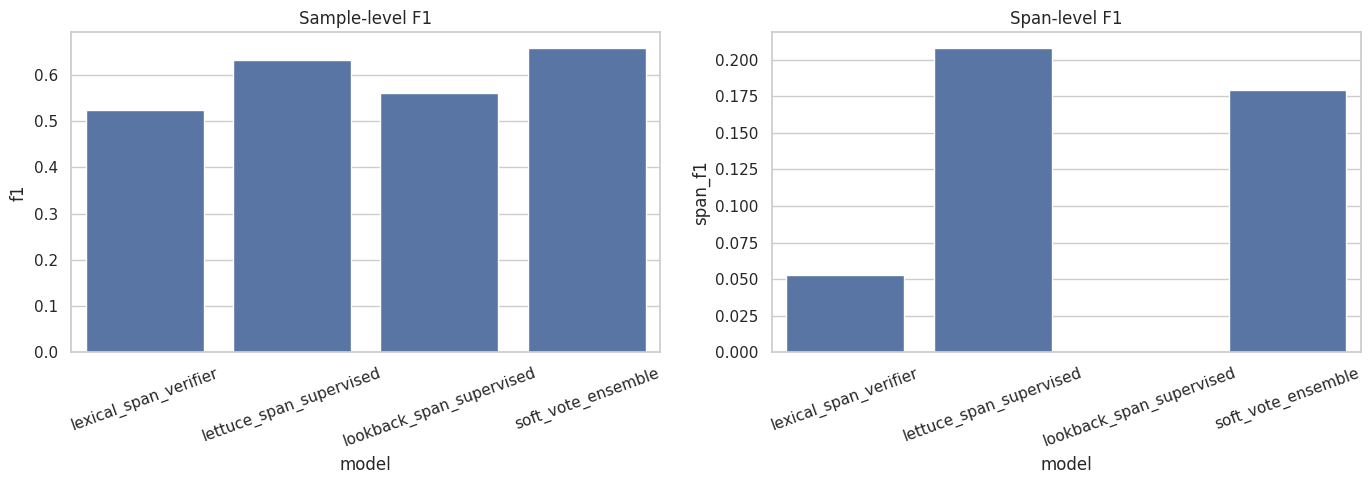

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x="model", y="f1", ax=axes[0])
axes[0].set_title("Sample-level F1")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=summary, x="model", y="span_f1", ax=axes[1])
axes[1].set_title("Span-level F1")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 11. Error analysis helper


In [53]:
def show_errors(df, score_col, pred_col, span_col, only_type=None, n=10):
    sub = df.copy()
    if only_type is not None:
        sub = sub[sub["corruption_type"] == only_type]

    mistakes = sub[sub["label"] != sub[pred_col]].copy()
    mistakes = mistakes.sort_values(score_col, ascending=False).head(n)

    cols = ["corruption_type", "label", pred_col, score_col, "query", "output", span_col]
    return mistakes[cols]

show_errors(ensemble_df, score_col="ensemble_score", pred_col="ensemble_pred", span_col="ensemble_spans", n=5)


,corruption_type,label,ensemble_pred,ensemble_score,query,output,ensemble_spans
108,clean,0,1,0.673630,Could you let me know what languages are suppo...,The supported languages for text analysis task...,"[{'start': 28, 'end': 32, 'text': 'text', 'typ..."
17,clean,0,1,0.652265,What kind of stats are usually tracked for NBA...,It seems there was no specific data returned f...,"[{'start': 87, 'end': 94, 'text': 'However', '..."
548,overgeneration,0,1,0.629697,Could you please provide the date when the Ear...,The date when Earth was closest to the sun in ...,"[{'start': 0, 'end': 67, 'text': 'The date whe..."
755,missing_tool,0,1,0.629697,Could you please provide the date when the Ear...,The date when Earth was closest to the sun in ...,"[{'start': 0, 'end': 67, 'text': 'The date whe..."
718,missing_tool,0,1,0.624329,"Hey, I'm curious! Do you happen to know how ma...","Based on the data returned, it can be stated t...","[{'start': 0, 'end': 5, 'text': 'Based', 'type..."


In [54]:
from pathlib import Path
import json
import pandas as pd

export_dir = Path("analysis_exports")
export_dir.mkdir(exist_ok=True)

# 1. Summary tables
summary.to_csv(export_dir / "summary_metrics.csv", index=False)
by_type_summary.to_csv(export_dir / "by_type_metrics.csv", index=False)

# 2. Full prediction tables
def _serialize_df(df, span_cols):
    df = df.copy()
    for col in span_cols:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: json.dumps(x, ensure_ascii=False))
    if "hallucination_labels" in df.columns:
        df["hallucination_labels"] = df["hallucination_labels"].apply(
            lambda x: json.dumps(x, ensure_ascii=False)
        )
    if "meta" in df.columns:
        df["meta"] = df["meta"].apply(lambda x: json.dumps(x, ensure_ascii=False))
    return df

_serialize_df(test_df_lex, ["lexical_spans"]).to_csv(
    export_dir / "test_predictions_lexical.csv", index=False
)

_serialize_df(test_df_lettuce, ["lettuce_spans"]).to_csv(
    export_dir / "test_predictions_lettuce.csv", index=False
)

_serialize_df(test_df_lbl, ["lbl_spans"]).to_csv(
    export_dir / "test_predictions_lookback.csv", index=False
)

_serialize_df(ensemble_df, ["ensemble_spans"]).to_csv(
    export_dir / "test_predictions_ensemble.csv", index=False
)

# 3. False positives / false negatives for quick inspection
def save_errors(df, pred_col, score_col, span_col, prefix):
    fp = df[(df["label"] == 0) & (df[pred_col] == 1)].copy()
    fn = df[(df["label"] == 1) & (df[pred_col] == 0)].copy()

    fp = _serialize_df(fp, [span_col]).sort_values(score_col, ascending=False)
    fn = _serialize_df(fn, [span_col]).sort_values(score_col, ascending=True)

    fp.to_csv(export_dir / f"{prefix}_false_positives.csv", index=False)
    fn.to_csv(export_dir / f"{prefix}_false_negatives.csv", index=False)

save_errors(test_df_lex, "lex_pred", "lex_score", "lexical_spans", "lexical")
save_errors(test_df_lettuce, "lettuce_pred", "lettuce_score", "lettuce_spans", "lettuce")
save_errors(test_df_lbl, "lbl_pred", "lbl_score", "lbl_spans", "lookback")
save_errors(ensemble_df, "ensemble_pred", "ensemble_score", "ensemble_spans", "ensemble")

# 4. Small manifest so another person knows what is what
manifest = {
    "files": {
        "summary_metrics.csv": "overall metrics for each method",
        "by_type_metrics.csv": "metrics broken down by corruption type",
        "test_predictions_lexical.csv": "full lexical baseline predictions on test set",
        "test_predictions_lettuce.csv": "full LettuceDetect-based predictions on test set",
        "test_predictions_lookback.csv": "full LookBack-style predictions on test set",
        "test_predictions_ensemble.csv": "full ensemble predictions on test set",
        "ensemble_false_positives.csv": "ensemble mistakes where clean sample was flagged",
        "ensemble_false_negatives.csv": "ensemble misses on hallucinated samples",
    }
}

with open(export_dir / "manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

print(f"Saved analysis artifacts to: {export_dir.resolve()}")
print("\nFiles:")
for p in sorted(export_dir.iterdir()):
    print("-", p.name)

Saved analysis artifacts to: /workspace/skoltech/hw_gen_ai1/analysis_exports

Files:
- by_type_metrics.csv
- ensemble_false_negatives.csv
- ensemble_false_positives.csv
- lettuce_false_negatives.csv
- lettuce_false_positives.csv
- lexical_false_negatives.csv
- lexical_false_positives.csv
- lookback_false_negatives.csv
- lookback_false_positives.csv
- manifest.json
- summary_metrics.csv
- test_predictions_ensemble.csv
- test_predictions_lettuce.csv
- test_predictions_lexical.csv
- test_predictions_lookback.csv


## 12. Notes

What changed in this version:
- raw tool-output JSON is normalized into factual natural-language context
- all three baselines now produce explicit hallucination spans
- `LettuceDetect` is evaluated natively as a span detector
- the LookBack-style baseline uses a stronger `Qwen/Qwen2.5-0.5B` backbone
- both sample-level and span-level metrics are reported

Recommended next upgrades:
- add a lightweight fine-tuned token classifier on top of the normalized context
- tune the lookback span threshold on a validation split
- add type-specific span labels (`contradiction`, `overgeneration`, `missing_tool`)
- compare direct span detection against BIO token tagging
